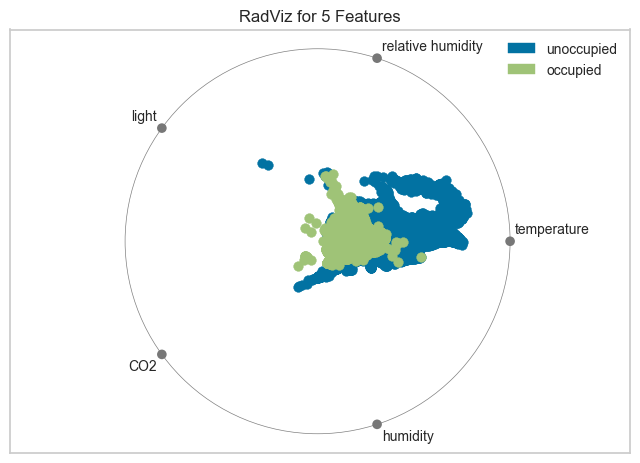

<Axes: title={'center': 'RadViz for 5 Features'}>

In [50]:
from yellowbrick.datasets import load_occupancy
from yellowbrick.features import RadViz

# Load the classification dataset
X, y = load_occupancy()

# Specify the target classes
classes = ["unoccupied", "occupied"]

# Instantiate the visualizer
visualizer = RadViz(classes=classes)

visualizer.fit(X, y)           # Fit the data to the visualizer
visualizer.transform(X)        # Transform the data
visualizer.show()              # Finalize and render the figure

In [51]:
import pandas as pd

# Convert X (usually numpy array) to DataFrame
df_X = pd.DataFrame(X)

# Convert y (usually numpy array) to Series
df_y = pd.Series(y, name='target')

# Optionally, combine into a single DataFrame
df = pd.concat([df_X, df_y], axis=1)

df


,temperature,relative humidity,light,CO2,humidity,target
0,23.180,27.2720,426.00,721.25,0.004793,1
1,23.150,27.2675,429.50,714.00,0.004783,1
2,23.150,27.2450,426.00,713.50,0.004779,1
3,23.150,27.2000,426.00,708.25,0.004772,1
4,23.100,27.2000,426.00,704.50,0.004757,1
...,...,...,...,...,...,...
20555,20.815,27.7175,429.75,1505.25,0.004213,1
20556,20.865,27.7450,423.50,1514.50,0.004230,1
20557,20.890,27.7450,423.50,1521.50,0.004237,1
20558,20.890,28.0225,418.75,1632.00,0.004279,1


## Lifestyle test

In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split

# load data
df = pd.read_csv("../lifestyle_sustainability_data.csv")

# handle these better with your own dataset, here we are simply dropping these
df = df.drop(['ParticipantID'], axis=1)


In [53]:
# this just converts the value of column to 0 or 1
# factorize in pandas works too, but only one column at a time
from sklearn.preprocessing import LabelEncoder
variables = ["SustainableBrands"]
encoder = LabelEncoder()
df[variables] = df[variables].apply(encoder.fit_transform)

In [54]:
 # this example is using the housing data from Moodle
varlist_three = ["CommunityInvolvement", "PhysicalActivities"]
varlist_four = ["LocalFoodFrequency", "ClothingFrequency", "UsingPlasticProducts"]

# Defining the map function
def binary_map_three(x):
    return x.map({'Low': 0, "Moderate": 1, "High": 2})

# Defining the map function
def binary_map_four(x):
    return x.map({'Rarely': 0, "Sometimes": 1, "Often": 2, "Always": 3})

# Applying the function to the housing list
df[varlist_three] = df[varlist_three].apply(binary_map_three)
df[varlist_four] = df[varlist_four].apply(binary_map_four)

In [55]:
 # this makes multiple columns with the variable (Separate for yes/no)
from sklearn.preprocessing import OneHotEncoder
variables = ["Location", "DietType", "TransportationMode", "EnergySource", "HomeType", "Gender", "DisposalMethods"]

# use encoder
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)

In [56]:
# CommunityInvolvement                 118
# UsingPlasticProducts                  95
# PhysicalActivities                   108

df['CommunityInvolvement'] = df['CommunityInvolvement'].fillna(0.0)
df['UsingPlasticProducts'] = df['UsingPlasticProducts'].fillna(3.0)
df['PhysicalActivities'] = df['PhysicalActivities'].fillna(0.0)

In [57]:
# we can always remove one of the onehotencoded variables, 
# remove: 'DietType_Mostly Plant-Based',  'TransportationMode_Walk',  'EnergySource_Renewable', 'HomeType_Other', 'Gender_Prefer not to say', 'DisposalMethods_Recycling'
removables = ['DietType_Mostly Plant-Based',  'TransportationMode_Walk',  'EnergySource_Renewable', 'HomeType_Other', 'Gender_Prefer not to say', 'DisposalMethods_Recycling']
df = df.drop(removables, axis=1)

In [58]:
# XGBoost requires ordinals to be from 0 onwards
# let's fix that
df['Rating'] = df['Rating'] - 1.0
df['Rating'] = df['Rating'].astype(int)

### We can use RadViz for multiclass, probably need to decide which variables to use though

Potentially a tool to visualize overlapping.

In [59]:

# Define features and target
X = df[['EnvironmentalAwareness', "Age", 'MonthlyWaterConsumption']]
y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

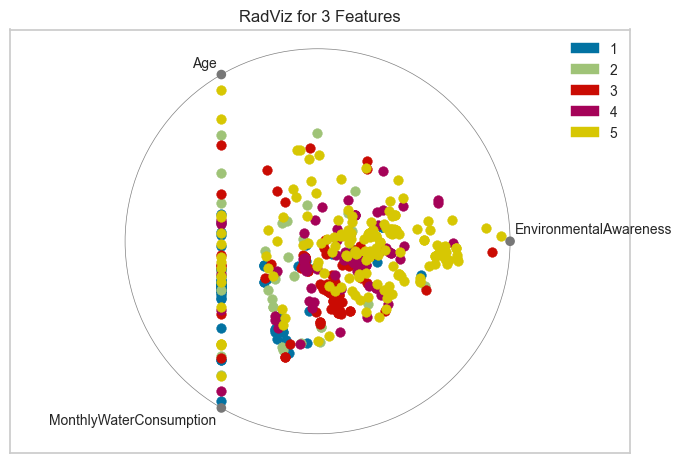

<Axes: title={'center': 'RadViz for 3 Features'}>

In [60]:
# Specify the target classes
classes = ["1", "2", "3", "4", "5"]

# Instantiate the visualizer
visualizer = RadViz(classes=classes)

visualizer.fit(X, y)           # Fit the data to the visualizer
visualizer.transform(X)        # Transform the data
visualizer.show()              # Finalize and render the figure

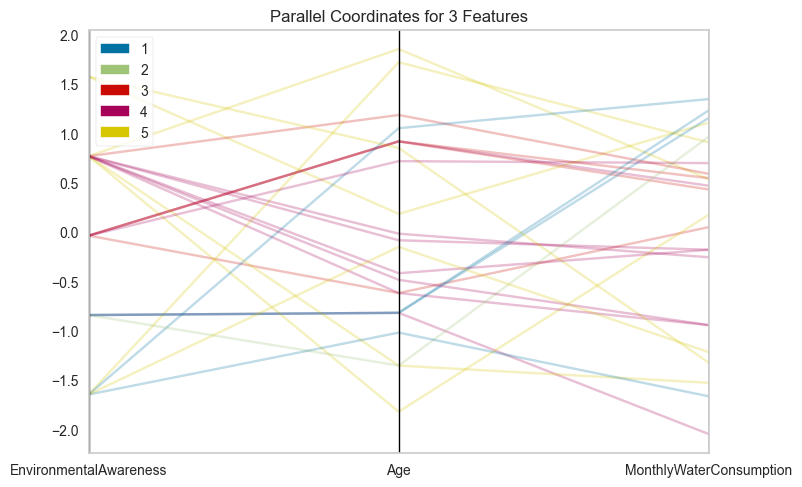

<Axes: title={'center': 'Parallel Coordinates for 3 Features'}>

In [62]:
from yellowbrick.features import ParallelCoordinates

# Specify the features of interest and the classes of the target
features = X.columns
classes = ["1", "2", "3", "4", "5"]

# Instantiate the visualizer
visualizer = ParallelCoordinates(
    classes=classes, features=features, sample=0.05, shuffle=True, normalize='standard'
)

# Fit and transform the data to the visualizer
visualizer.fit_transform(X, y)

# Finalize the title and axes then display the visualization
visualizer.show()